In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def calculate_specific_humidity(temperature_celsius, relative_humidity_percent, atmospheric_pressure_hpa):
    """
    Calculates specific humidity from temperature, relative humidity, and atmospheric pressure.

    Args:
        temperature_celsius (float): Temperature in degrees Celsius.
        relative_humidity_percent (float): Relative humidity as a percentage (e.g., 75 for 75%).
        atmospheric_pressure_hpa (float): Atmospheric pressure in hectopascals (hPa).

    Returns:
        float: Specific humidity in kg/kg.
    """

    # 1. Calculate the Saturation Vapor Pressure (Ps) using the Magnus-Tetens formula.
    ps = 6.112 * np.exp((17.62 * temperature_celsius) / (243.12 + temperature_celsius))

    # 2. Calculate the Actual Vapor Pressure (Pv) from relative humidity.
    pv = ps * (relative_humidity_percent / 100)

    # 3. Calculate the Specific Humidity (q) using the atmospheric pressure and actual vapor pressure.
    # The constant 0.622 is the ratio of the molecular weight of water vapor to dry air.
    q = (0.622 * pv) / (atmospheric_pressure_hpa - pv)

    return q

In [3]:
atto_raw_file = '/Net/Groups/BSI/people/sbotia/data_input/ATTOdata_4LSM/ATTO_data_30min_model_input_evaluation_v1_2014-2023.csv'
df_atto_raw = pd.read_csv(atto_raw_file)
df_atto_raw['datetime'] = pd.to_datetime(df_atto_raw['datetime'])
df_atto_raw.set_index('datetime', inplace=True)
df_atto_raw['Year'] = df_atto_raw.index.year
df_atto_raw['Month'] = df_atto_raw.index.month
df_atto_raw['Day_of_year'] = df_atto_raw.index.dayofyear
df_atto_raw['q_36m']=calculate_specific_humidity(df_atto_raw['Tair_36m'],df_atto_raw['RH_36m'] , df_atto_raw['AP_36m_kPa']*10 )

In [4]:
df_zf2 = pd.read_csv("../data/BR-Ma2/AMF_BR-Ma2_BASE_HH_1-5.csv", delimiter = ',', skiprows=2)
df_zf2['datetime'] = pd.to_datetime(df_zf2['TIMESTAMP_START'], format='%Y%m%d%H%M')
df_zf2.set_index('datetime', inplace=True)
df_zf2 = df_zf2.replace(-9999.0, np.nan)
df_zf2['Year'] = df_zf2.index.year
df_zf2['Month'] = df_zf2.index.month
df_zf2['Day_of_year'] = df_zf2.index.dayofyear
df_zf2['Q']=calculate_specific_humidity(df_zf2['TA'],df_zf2['RH'] , df_zf2['PA']*10)

In [37]:
vars_atto = ["Tair_36m", "q_36m", "LW_atm_calc", 'SW_in_GF (W/m2)',  'AP_36m_kPa', 'Rainfall']
vars_zf2 = ["TA", "Q", "LW_IN", 'SW_IN_PI_F',  'PA', 'P']

In [ ]:
# Identify where NaNs are
mask = df_atto_raw[vars_atto[0]].isna()


if df_atto_raw[vars_atto[0]].notna().sum() == df_atto_raw.shape[0]:
    print("Contains no nan. No gapfilling needed")    

else:
    # Find start and end points of NaN sequences
    nan_groups = (mask != mask.shift()).cumsum()  # group consecutive values
    nan_spans = (
        df_atto_raw[mask]
        .groupby(nan_groups[mask])
        .apply(lambda g: pd.Series({
            "start": g.index[0],
            "end": g.index[-1],
            "duration": g.index[-1] - g.index[0]
        }))
    ).reset_index(drop=True)

    

In [78]:
nan_spans.sort_values(by='duration', ascending=False)

,start,end,duration
20,2021-05-28 20:00:00,2021-07-14 19:30:00,46 days 23:30:00
27,2021-11-16 20:00:00,2021-12-08 11:00:00,21 days 15:00:00
0,2015-08-25 08:00:00,2015-09-04 10:00:00,10 days 02:00:00
22,2021-08-03 20:30:00,2021-08-10 19:30:00,6 days 23:00:00
8,2016-02-10 18:00:00,2016-02-14 08:30:00,3 days 14:30:00
25,2021-11-10 20:00:00,2021-11-14 06:30:00,3 days 10:30:00
41,2023-02-07 12:00:00,2023-02-10 19:30:00,3 days 07:30:00
10,2020-01-24 19:30:00,2020-01-26 19:00:00,1 days 23:30:00
13,2020-11-29 20:00:00,2020-12-01 19:30:00,1 days 23:30:00
3,2015-11-25 00:00:00,2015-11-26 14:00:00,1 days 14:00:00


In [ ]:
vs = vars_atto[0]

se =  df_atto_raw[vs]
seasonal_cycle = se.groupby(se.index.dayofyear).mean()
deseasonalized = se - se.index.dayofyear.map(seasonal_cycle)
daily_cycle = deseasonalized.groupby([se.index.hour, se.index.minute]).mean()

def expected_from_climatology(ts):
    doy = ts.dayofyear
    hm = (ts.hour, ts.minute)
    return daily_cycle.loc[hm] + seasonal_cycle.loc[doy]

expected = pd.DataFrame(se.index.to_series().apply(expected_from_climatology))
expected.rename(columns={expected.columns[0]: vs}, inplace=True)

In [171]:
# 2. Seasonal mean (day-of-year)
seasonal_cycle = se.groupby(se.index.dayofyear).mean()

# 3. Deseasonalize to get daily cycle
deseasonalized = se - se.index.dayofyear.map(seasonal_cycle)
daily_cycle = deseasonalized.groupby([se.index.hour, se.index.minute]).mean()

# 4. Compute residuals (observed - seasonal - daily)
residuals = se - (se.index.dayofyear.map(seasonal_cycle) + se.index.to_series().apply(lambda ts: daily_cycle.loc[(ts.hour, ts.minute)]))


# 5. Identify missing positions
missing_mask = se.isna()

# 6. Vectorized stochastic gapfill
# Create array to hold filled values
filled_values = se.copy()

# Extract hour/minute for all missing timestamps
hm_missing = np.array(list(zip(se.index[missing_mask].hour, se.index[missing_mask].minute)))


for hm in np.unique(hm_missing, axis=0):
    hour, minute = hm
    idx_missing = missing_mask & (se.index.hour == hour) & (se.index.minute == minute)
    
    # Candidate residuals
    candidates = residuals[(residuals.index.hour == hour) & 
                           (residuals.index.minute == minute) & 
                           (~residuals.isna())].values
    
    n_missing = idx_missing.sum()
    if len(candidates) == 0:
        sampled = np.zeros(n_missing)
    else:
        sampled = np.random.choice(candidates, size=n_missing, replace=True)
    
    # Seasonal + daily mean
    seasonal_mean = seasonal_cycle[se.index[idx_missing].dayofyear].to_numpy()  # array
    daily_mean = daily_cycle.loc[(hour, minute)]  # scalar
    
    mean_values = seasonal_mean + daily_mean
    
    # Fill missing positions
    filled_values[idx_missing] = mean_values + sampled

# 7. Create filled_flag
filled_flag = missing_mask.astype(int)

# 8. Resulting filled series
filled_series = filled_values

In [176]:
# # Optional: combine into DataFrame
df_filled = pd.DataFrame({
    vs: se,
    "filled_flag": filled_flag,
    "filled": filled_series
})

In [177]:
df_filled

,Tair_36m,filled_flag,filled
datetime,,,
2014-01-01 00:00:00,25.202333,0,25.202333
2014-01-01 00:30:00,24.951333,0,24.951333
2014-01-01 01:00:00,24.761333,0,24.761333
2014-01-01 01:30:00,24.455667,0,24.455667
2014-01-01 02:00:00,24.241667,0,24.241667
...,...,...,...
2023-12-31 17:00:00,24.024000,0,24.024000
2023-12-31 17:30:00,23.885000,0,23.885000
2023-12-31 18:00:00,23.766667,0,23.766667


In [173]:
filled_flag = se.isna().astype(int)
dfs = pd.DataFrame({
    vs: se,
    f'{vs}_flag': filled_flag
})

In [174]:
dfs[f"{vs}_filled"] = dfs[vs].copy()
dfs.loc[dfs[f'{vs}_flag'] == 1, f"{vs}_filled"] = expected.loc[dfs[f'{vs}_flag'] ==1, vs ]

(np.float64(18748.0), np.float64(18840.0))

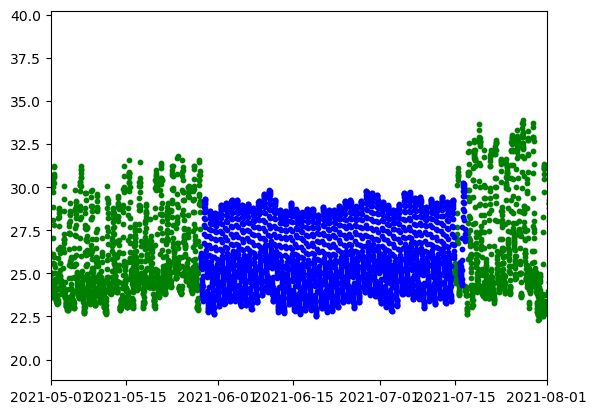

In [175]:
plt.scatter(dfs.index[dfs[f"{vs}_flag"] == 0],
            dfs[f"{vs}_filled"][dfs[f"{vs}_flag"] == 0],
            color="green", label="Observed", s=10)
plt.scatter(dfs.index[dfs[f"{vs}_flag"] == 1],
            dfs[f"{vs}_filled"][dfs[f"{vs}_flag"] == 1],
            color="blue", label="Observed", s= 10)
plt.xlim(pd.Timestamp("2021-05-01"), pd.Timestamp("2021-08-01"))

In [179]:
df_filled

,Tair_36m,filled_flag,filled
datetime,,,
2014-01-01 00:00:00,25.202333,0,25.202333
2014-01-01 00:30:00,24.951333,0,24.951333
2014-01-01 01:00:00,24.761333,0,24.761333
2014-01-01 01:30:00,24.455667,0,24.455667
2014-01-01 02:00:00,24.241667,0,24.241667
...,...,...,...
2023-12-31 17:00:00,24.024000,0,24.024000
2023-12-31 17:30:00,23.885000,0,23.885000
2023-12-31 18:00:00,23.766667,0,23.766667


(np.float64(18748.0), np.float64(18840.0))

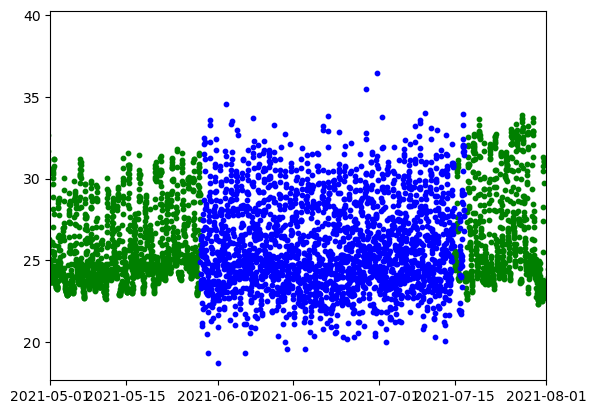

In [182]:
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 0],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 0],
            color="green", label="Observed", s=10)
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 1],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 1],
            color="blue", label="Observed", s=10)
plt.xlim(pd.Timestamp("2021-05-01"), pd.Timestamp("2021-08-01"))

In [199]:
import numpy as np
import pandas as pd

# === PARAMETERS ===
vs = vars_atto[0]           # variable name
anchor_days = 14            # length of before/after anchors in days

# === 1. Original series ===
se = df_atto_raw[vs]  # Series
freq = (se.index[1] - se.index[0])  # timedelta for frequency
anchor_points = int(anchor_days * 24 * 60 / (freq.seconds / 60))  # convert days -> number of points

# === 2. Seasonal mean (day-of-year) ===
seasonal_cycle = se.groupby(se.index.dayofyear).mean()

# === 3. Deseasonalize to get daily cycle ===
deseasonalized = se - se.index.dayofyear.map(seasonal_cycle)
daily_cycle = deseasonalized.groupby([se.index.hour, se.index.minute]).mean()

# === 4. Compute expected mean values ===
expected = pd.Series(
    seasonal_cycle[se.index.dayofyear].values +
    se.index.to_series().map(lambda ts: daily_cycle.loc[(ts.hour, ts.minute)]).values,
    index=se.index
)

# === 5. Identify missing values ===
filled_flag = se.isna().astype(int)

# === 6. Initial fill with seasonal+daily mean ===
filled_series = se.copy()
filled_series[filled_flag == 1] = expected[filled_flag == 1]

# === 7. Smooth long gaps with quantile-based ramping ===
mask = filled_flag == 1
gap_groups = (mask != mask.shift()).cumsum()
gaps = filled_series[mask].groupby(gap_groups[mask])

for _, gap in gaps:
    start_idx = gap.index[0]
    end_idx = gap.index[-1]
    
    # Anchor indices (before and after gap)
    start_anchor_idx = max(se.index.get_loc(start_idx) - anchor_points, 0)
    end_anchor_idx = min(se.index.get_loc(end_idx) + anchor_points + 1, len(se))
    
    # Start/end anchor data
    start_anchor_data = filled_series.iloc[start_anchor_idx:se.index.get_loc(start_idx)]
    end_anchor_data = filled_series.iloc[se.index.get_loc(end_idx)+1:end_anchor_idx]
    
    # Median for central tendency
    start_median = start_anchor_data.quantile(0.5)
    end_median = end_anchor_data.quantile(0.5)
    
    # IQR for variability
    start_iqr = start_anchor_data.quantile(0.75) - start_anchor_data.quantile(0.25)
    end_iqr = end_anchor_data.quantile(0.75) - end_anchor_data.quantile(0.25)
    
    # Linear ramp
    n_gap = len(gap)
    alpha = np.linspace(0, 1, n_gap)
    
    ramp_median = (1 - alpha) * start_median + alpha * end_median
    ramp_iqr = (1 - alpha) * start_iqr + alpha * end_iqr
    
    # Apply ramp: seasonal+daily mean + scaled variability (IQR)
    gap_mean = expected[gap.index].values
    filled_series.iloc[se.index.get_loc(start_idx):se.index.get_loc(end_idx)+1] = gap_mean + ramp_iqr

# === 8. Combine into DataFrame ===
df_filled = pd.DataFrame({
    vs: se,
    "filled_flag": filled_flag,
    "filled": filled_series
})

# === 9. Optional: inspect ===
print(df_filled.head())
print(df_filled[df_filled["filled_flag"] == 1].head())


                      Tair_36m  filled_flag     filled
datetime                                              
2014-01-01 00:00:00  25.202333            0  25.202333
2014-01-01 00:30:00  24.951333            0  24.951333
2014-01-01 01:00:00  24.761333            0  24.761333
2014-01-01 01:30:00  24.455667            0  24.455667
2014-01-01 02:00:00  24.241667            0  24.241667
                     Tair_36m  filled_flag     filled
datetime                                             
2015-08-25 08:00:00       NaN            1  31.150719
2015-08-25 08:30:00       NaN            1  31.788876
2015-08-25 09:00:00       NaN            1  32.406725
2015-08-25 09:30:00       NaN            1  32.983051
2015-08-25 10:00:00       NaN            1  33.482278


In [207]:
import numpy as np
import pandas as pd

# === PARAMETERS ===
vs = vars_atto[0]           # variable name
anchor_days = 14            # length of before/after anchors in days

# === 1. Original series ===
se = df_atto_raw[vs]  # Series
freq = (se.index[1] - se.index[0])  # timedelta for frequency
anchor_points = int(anchor_days * 24 * 60 / (freq.seconds / 60))  # convert days -> number of points

# === 2. Seasonal mean (day-of-year) ===
seasonal_cycle = se.groupby(se.index.dayofyear).mean()

# === 3. Deseasonalize to get daily cycle ===
deseasonalized = se - se.index.dayofyear.map(seasonal_cycle)
daily_cycle = deseasonalized.groupby([se.index.hour, se.index.minute]).mean()

# === 4. Compute expected mean values ===
expected = pd.Series(
    seasonal_cycle[se.index.dayofyear].values +
    se.index.to_series().map(lambda ts: daily_cycle.loc[(ts.hour, ts.minute)]).values,
    index=se.index
)

# === 5. Identify missing values ===
filled_flag = se.isna().astype(int)

# === 6. Initial fill with seasonal+daily mean ===
filled_series = se.copy()
filled_series[filled_flag == 1] = expected[filled_flag == 1]

# === 7. Smooth long gaps with quantile-based ramping ===
mask = filled_flag == 1
gap_groups = (mask != mask.shift()).cumsum()
gaps = filled_series[mask].groupby(gap_groups[mask])

for _, gap in gaps:
    start_idx = gap.index[0]
    end_idx = gap.index[-1]
    
    # Anchor indices (before and after gap)
    start_anchor_idx = max(se.index.get_loc(start_idx) - anchor_points, 0)
    end_anchor_idx = min(se.index.get_loc(end_idx) + anchor_points + 1, len(se))
    
    # Start/end anchor data
    start_anchor_data = filled_series.iloc[start_anchor_idx:se.index.get_loc(start_idx)]
    end_anchor_data = filled_series.iloc[se.index.get_loc(end_idx)+1:end_anchor_idx]
    
    # Median for central tendency
    start_median = start_anchor_data.quantile(0.5)
    end_median = end_anchor_data.quantile(0.5)
    
    # IQR for variability
    start_iqr = start_anchor_data.quantile(0.75) - start_anchor_data.quantile(0.25)
    end_iqr = end_anchor_data.quantile(0.75) - end_anchor_data.quantile(0.25)
    
    # Linear ramp
    n_gap = len(gap)
    alpha = np.linspace(0, 1, n_gap)
    
    ramp_median = (1 - alpha) * start_median + alpha * end_median
    ramp_iqr = (1 - alpha) * start_iqr + alpha * end_iqr
    
    # Apply ramp: seasonal+daily mean + scaled variability (IQR)
    gap_mean = expected[gap.index].values
    filled_series.iloc[se.index.get_loc(start_idx):se.index.get_loc(end_idx)+1] = gap_mean + np.random.uniform(-0.2, 0.6, size=n_gap) * ramp_iqr

# === 8. Combine into DataFrame ===
df_filled = pd.DataFrame({
    vs: se,
    "filled_flag": filled_flag,
    "filled": filled_series
})

# === 9. Optional: inspect ===
print(df_filled.head())
print(df_filled[df_filled["filled_flag"] == 1].head())


                      Tair_36m  filled_flag     filled
datetime                                              
2014-01-01 00:00:00  25.202333            0  25.202333
2014-01-01 00:30:00  24.951333            0  24.951333
2014-01-01 01:00:00  24.761333            0  24.761333
2014-01-01 01:30:00  24.455667            0  24.455667
2014-01-01 02:00:00  24.241667            0  24.241667
                     Tair_36m  filled_flag     filled
datetime                                             
2015-08-25 08:00:00       NaN            1  26.475877
2015-08-25 08:30:00       NaN            1  29.179317
2015-08-25 09:00:00       NaN            1  30.276843
2015-08-25 09:30:00       NaN            1  30.996592
2015-08-25 10:00:00       NaN            1  28.360297


(np.float64(18748.0), np.float64(18840.0))

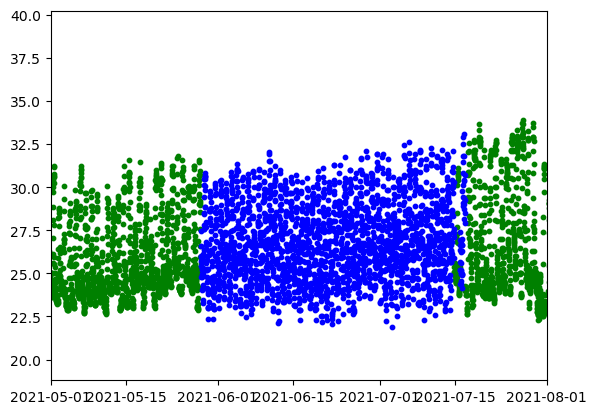

In [208]:
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 0],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 0],
            color="green", label="Observed", s=10)
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 1],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 1],
            color="blue", label="Observed", s=10)
plt.xlim(pd.Timestamp("2021-05-01"), pd.Timestamp("2021-08-01"))

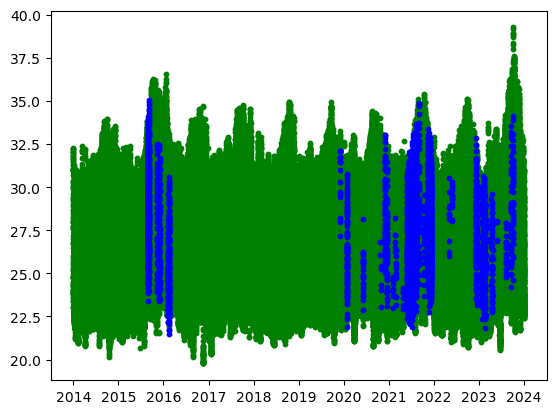

In [211]:
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 0],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 0],
            color="green", label="Observed", s=10)
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 1],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 1],
            color="blue", label="Observed", s=10)
#plt.xlim(pd.Timestamp("2021-05-01"), pd.Timestamp("2021-06-01"))

(np.float64(16801.0), np.float64(16861.0))

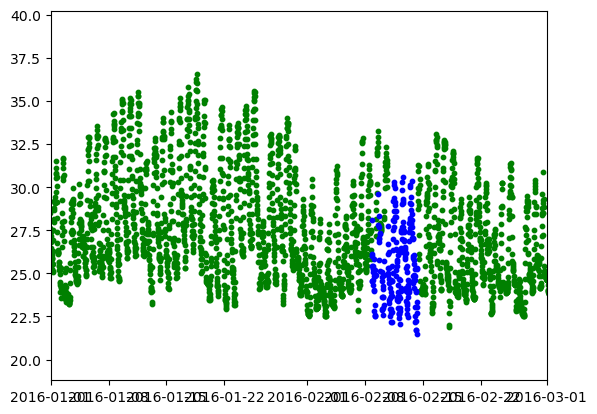

In [215]:
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 0],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 0],
            color="green", label="Observed", s=10)
plt.scatter(df_filled.index[df_filled[f"filled_flag"] == 1],
            df_filled[f"filled"][df_filled[f"filled_flag"] == 1],
            color="blue", label="Observed", s=10)
plt.xlim(pd.Timestamp("2016-01-01"), pd.Timestamp("2016-03-01"))

In [191]:
end_idx

Timestamp('2023-10-05 08:30:00')